# Project Overview and Dataset

### Our task is to classify a patient as either having diabtes (class1) or no diabetes(class0).

### We use<b> Pima Diabetes Database</b> which is available on <a href = https://www.kaggle.com> Kaggle </a> You can view and download the dataset from this  <a href = https://www.kaggle.com/uciml/pima-indians-diabetes-database> Link <a>. 

## Read Dataset

In [50]:
# To read dataset with pandas.
import pandas as pd

data = pd.read_csv("../data/raw/Credit_Card_Applications.csv")

data.head()

,CustomerID,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,Class
0,15776156,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213,0
1,15739548,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1,0
2,15662854,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1,0
3,15687688,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1,1
4,15715750,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159,1


In [51]:
# To know you have Missing values in dataset.
data.dtypes

CustomerID      int64
A1              int64
A2            float64
A3            float64
A4              int64
A5              int64
A6              int64
A7            float64
A8              int64
A9              int64
A10             int64
A11             int64
A12             int64
A13             int64
A14             int64
Class           int64
dtype: object

## Splitting dataset to input and output

In [52]:
# Split data into input and output.
data_input = data.drop(columns=["CustomerID", "Class"])
data_output = data["Class"]

In [53]:
# Show input from dataset only.
data_input.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14
0,1,22.08,11.46,2,4,4,1.585,0,0,0,1,2,100,1213
1,0,22.67,7.00,2,8,4,0.165,0,0,0,0,2,160,1
2,0,29.58,1.75,1,4,4,1.250,0,0,0,1,2,280,1
3,0,21.67,11.50,1,5,3,0.000,1,1,11,1,2,0,1
4,1,20.17,8.17,2,6,4,1.960,1,1,14,0,2,60,159


In [54]:
# Show output from dataset only.
data_output.head()

0    0
1    0
2    0
3    1
4    1
Name: Class, dtype: int64

# Splitting dataset to (Training, Validation and Testing)

In [55]:
# Split data into tree parts ( Training , Valdiation , Testing ).
from sklearn.model_selection import train_test_split

x, x_test, y, y_test = train_test_split(data_input, data_output, test_size = 0.2 , random_state = 1)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size = 0.33 , random_state = 1)

In [56]:
# Show all columns only of ( Training , Valdiation , Testing ).
print(x_train.shape[0])
print(x_val.shape[0])
print(x_test.shape[0])

369
183
138


## Feature Scaling

In [57]:
# The first type of ensemble.
from sklearn.preprocessing import StandardScaler

In [58]:
# Take object from StandardScaler.
scaler = StandardScaler()

In [59]:
# Training Model.
scaler.fit(x_train)

StandardScaler()

In [60]:
# The range of input data is very defferent so that make it in nearly range. ( Using ==> transform )
x_train_scaler = scaler.transform(x_train)
x_val_scaler = scaler.transform(x_val)
x_test_scaler = scaler.transform(x_test)

## Helper Function: Evaluate Classifier

In [61]:
# Calculate accuracy of traing.
from sklearn.metrics import accuracy_score

def evalute_model(clf, x_train, x_val, y_train, y_val):
    
    """
    This Function is used to take any model and traing it then predict output and caluclate accuracy.
    Input:
    clf ==> Any model need to calculate accuracy.
    x_train ==> Part of dataset that train data with it.
    x_val ==> Part of dataset that see the validation of data with it.
    Output:
    y_train ==> Part of dataset that train data with it.
    y_val ==> Part of dataset that see the validation of data with it.
    Calculate accuracy of training and validation and return them.
    """
    # Train Model.
    clf.fit(x_train, y_train)
    
    # Predict values of Train and valdation.
    y_pred_train = clf.predict(x_train)
    y_pred_val = clf.predict(x_val)
    
    # Calculate accuracy of train and testing.
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val = accuracy_score(y_val, y_pred_val)
    
    print(clf.__class__.__name__)
    print("Accuracy of training: ",acc_train)
    print("Accuracy of valdation: ",acc_val)
    print('-------------------------------------')
    return acc_train, acc_val

# Voting Classifier

In [62]:
# Calling all the model that use it with using sklearn.
# Calling VotingClassifier from ensemble. VotingClassifier ==> Take the choice of the most of model choice it.

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier

In [63]:
# Using all model and give him the hyperparameter.
tree_clf = DecisionTreeClassifier(max_depth = 3, random_state = 1)
logistic_clf = LogisticRegression(random_state = 1)
svc_clf = SVC(random_state = 1)

In [64]:
# Calculate the best max_depth should use in decision tree.
max_depth_values = [1,2,3,4,5,6,7,8]
acc_train_values = []
acc_val_values = []

for max_depth in max_depth_values:
    model = DecisionTreeClassifier(max_depth = max_depth, random_state = 1)
    acc_train, acc_val = evalute_model(model, x_train_scaler, x_val_scaler, y_train, y_val)
    acc_train_values.append(acc_train)
    acc_val_values.append(acc_val)

DecisionTreeClassifier
Accuracy of training:  0.8373983739837398
Accuracy of valdation:  0.8579234972677595
-------------------------------------
DecisionTreeClassifier
Accuracy of training:  0.8428184281842819
Accuracy of valdation:  0.8579234972677595
-------------------------------------
DecisionTreeClassifier
Accuracy of training:  0.8563685636856369
Accuracy of valdation:  0.8306010928961749
-------------------------------------
DecisionTreeClassifier
Accuracy of training:  0.8943089430894309
Accuracy of valdation:  0.8579234972677595
-------------------------------------
DecisionTreeClassifier
Accuracy of training:  0.9132791327913279
Accuracy of valdation:  0.8469945355191257
-------------------------------------
DecisionTreeClassifier
Accuracy of training:  0.94579945799458
Accuracy of valdation:  0.7923497267759563
-------------------------------------
DecisionTreeClassifier
Accuracy of training:  0.975609756097561
Accuracy of valdation:  0.8306010928961749
-------------------

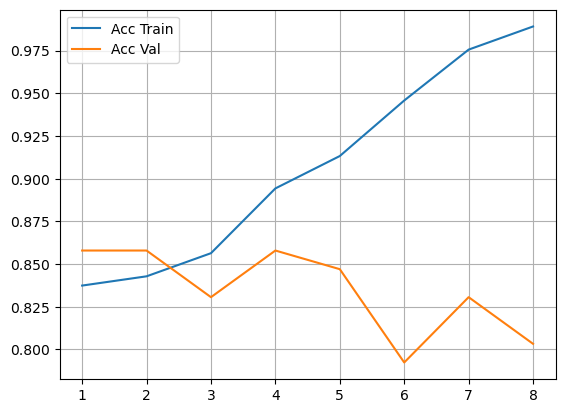

In [65]:
# Draw diagram to show the best max_dpth should use.
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(max_depth_values, acc_train_values, label = 'Acc Train')
plt.plot(max_depth_values, acc_val_values, label = 'Acc Val')
plt.legend()
plt.grid(axis = 'both')
plt.show()

In [66]:
# Put all models in list of tuples.
estimaters = [
    ('tree',tree_clf),
    ('logistic',logistic_clf),
    ('svc',svc_clf)
]

voting_clf = VotingClassifier(estimaters)

In [67]:
# Add voting_classifier to estimaters.
all_estimaters = estimaters + [('voting_clf',voting_clf)]

# Make three list to have ( name of model , accuracy_train , accuracy_val )
results = {
    
    'model': [],
    'acc_train':[],
    'acc_val':[]      
}

for (name,clf) in all_estimaters:
    acc_train , acc_val = evalute_model(clf, x_train_scaler,
                                        x_val_scaler, y_train, y_val)
    results['model'].append(name)
    results['acc_train'].append(acc_train)
    results['acc_val'].append(acc_val)

DecisionTreeClassifier
Accuracy of training:  0.8563685636856369
Accuracy of valdation:  0.8306010928961749
-------------------------------------
LogisticRegression
Accuracy of training:  0.8482384823848238
Accuracy of valdation:  0.8797814207650273
-------------------------------------
SVC
Accuracy of training:  0.8997289972899729
Accuracy of valdation:  0.8688524590163934
-------------------------------------
VotingClassifier
Accuracy of training:  0.8915989159891599
Accuracy of valdation:  0.8743169398907104
-------------------------------------


In [68]:
# Show all the result of model and voting_classifier either.
results

{'model': ['tree', 'logistic', 'svc', 'voting_clf'],
 'acc_train': [0.8563685636856369,
  0.8482384823848238,
  0.8997289972899729,
  0.8915989159891599],
 'acc_val': [0.8306010928961749,
  0.8797814207650273,
  0.8688524590163934,
  0.8743169398907104]}

In [69]:
# To be data very readble to read it should use DataFrame.
result_df = pd.DataFrame(results)

result_df

,model,acc_train,acc_val
0,tree,0.856369,0.830601
1,logistic,0.848238,0.879781
2,svc,0.899729,0.868852
3,voting_clf,0.891599,0.874317


# Bagging

In [70]:
# Bagging type of ensemble model. Ensemble Model dependant of ==> ( use alot of model in the same dataset )
from sklearn.ensemble import BaggingClassifier

In [71]:
best_values = [20,30,60,80,100,120,140,160]
acc_train_values = []
acc_val_values = []

for best_value in best_values:
    model = BaggingClassifier(
    LogisticRegression(random_state = 1), n_estimators = best_value,
    max_samples = 0.75, bootstrap = True, random_state = 1, n_jobs = -1,
)
    acc_train_bag, acc_val_bag = evalute_model(model, x_train_scaler, x_val_scaler, y_train, y_val)
    acc_train_values.append(acc_train_bag)
    acc_val_values.append(acc_val_bag)

BaggingClassifier
Accuracy of training:  0.8536585365853658
Accuracy of valdation:  0.8907103825136612
-------------------------------------
BaggingClassifier
Accuracy of training:  0.8509485094850948
Accuracy of valdation:  0.8852459016393442
-------------------------------------
BaggingClassifier
Accuracy of training:  0.8455284552845529
Accuracy of valdation:  0.8852459016393442
-------------------------------------
BaggingClassifier
Accuracy of training:  0.8455284552845529
Accuracy of valdation:  0.8907103825136612
-------------------------------------
BaggingClassifier
Accuracy of training:  0.8428184281842819
Accuracy of valdation:  0.8961748633879781
-------------------------------------
BaggingClassifier
Accuracy of training:  0.8455284552845529
Accuracy of valdation:  0.8852459016393442
-------------------------------------
BaggingClassifier
Accuracy of training:  0.8455284552845529
Accuracy of valdation:  0.8852459016393442
-------------------------------------
BaggingClassi

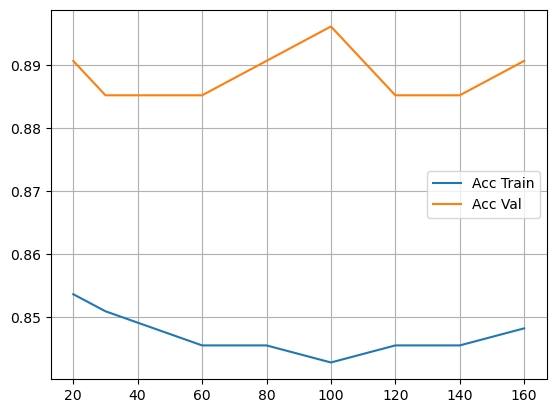

In [72]:
plt.plot(best_values, acc_train_values, label = "Acc Train")
plt.plot(best_values, acc_val_values, label = 'Acc Val')
plt.legend()
plt.grid(axis = 'both')
plt.show()

In [73]:
# Bagging / Pasting { be pasting if need to use Pasting ==> ( bootstrap = False ) }

# Call bagginf and use hyperparameter specific.
bag_clf = BaggingClassifier(
    LogisticRegression(random_state = 1), n_estimators = 120,
    max_samples = 0.75, bootstrap = True, random_state = 1, n_jobs = -1,
)

acc_train_bag, acc_val_bag = evalute_model(bag_clf, x_train_scaler, x_val_scaler, y_train, y_val)

BaggingClassifier
Accuracy of training:  0.8455284552845529
Accuracy of valdation:  0.8852459016393442
-------------------------------------


# Random Forest

In [74]:
# Using another type of ensemble called RandomForestClassifier.
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators = 250, max_depth = 6, random_state = 1)

acc_train_rf, acc_val_rf = evalute_model(rf_clf, x_train_scaler,
                                   x_val_scaler, y_train, y_val)

RandomForestClassifier
Accuracy of training:  0.9566395663956639
Accuracy of valdation:  0.8797814207650273
-------------------------------------


In [75]:
max_depth_values = [1,2,3,4,5,6,7,8]
acc_train_values = []
acc_val_values = []

for max_depth in max_depth_values:
    model = RandomForestClassifier(n_estimators = 250, max_depth = max_depth, random_state = 1)
    acc_train, acc_val = evalute_model(model, x_train_scaler,
                                   x_val_scaler, y_train, y_val)
    acc_train_values.append(acc_train)
    acc_val_values.append(acc_val)

RandomForestClassifier
Accuracy of training:  0.8292682926829268
Accuracy of valdation:  0.8579234972677595
-------------------------------------
RandomForestClassifier
Accuracy of training:  0.8590785907859079
Accuracy of valdation:  0.8797814207650273
-------------------------------------
RandomForestClassifier
Accuracy of training:  0.8699186991869918
Accuracy of valdation:  0.8797814207650273
-------------------------------------
RandomForestClassifier
Accuracy of training:  0.9024390243902439
Accuracy of valdation:  0.8743169398907104
-------------------------------------
RandomForestClassifier
Accuracy of training:  0.9214092140921409
Accuracy of valdation:  0.8852459016393442
-------------------------------------
RandomForestClassifier
Accuracy of training:  0.9566395663956639
Accuracy of valdation:  0.8797814207650273
-------------------------------------
RandomForestClassifier
Accuracy of training:  0.967479674796748
Accuracy of valdation:  0.8797814207650273
-----------------

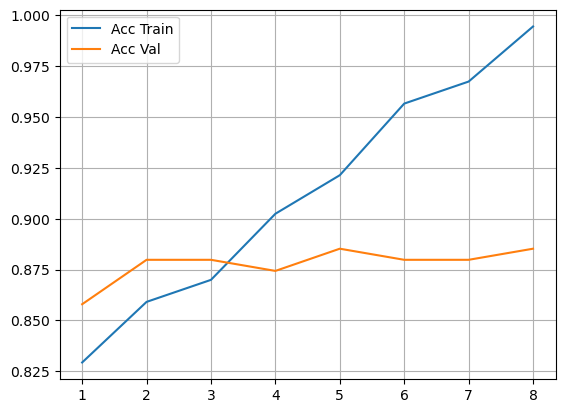

In [76]:
plt.plot(max_depth_values, acc_train_values, label = "Acc Train")
plt.plot(max_depth_values, acc_val_values, label = 'Acc Val')
plt.legend()
plt.grid(axis = 'both')
plt.show()

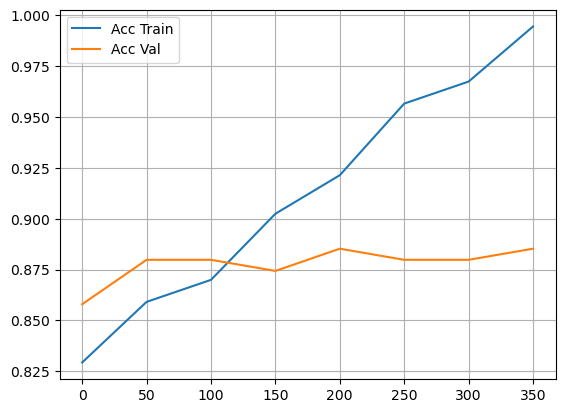

In [77]:
estimate_values = [0,50,100,150,200,250,300,350]

plt.plot(estimate_values, acc_train_values, label = "Acc Train")
plt.plot(estimate_values, acc_val_values, label = 'Acc Val')
plt.legend()
plt.grid(axis = 'both')
plt.show()

# Extemely Random Treees(Extra-Trees)

In [78]:
from sklearn.ensemble import ExtraTreesClassifier

ex_clf = ExtraTreesClassifier(n_estimators = 250, max_depth = 7, random_state = 1)

acc_train_ex, acc_val_ex = evalute_model(ex_clf, x_train_scaler,
                                   x_val_scaler, y_train, y_val)

ExtraTreesClassifier
Accuracy of training:  0.9349593495934959
Accuracy of valdation:  0.8633879781420765
-------------------------------------


In [79]:
max_depth_values = [1,2,3,4,5,6,7,8]
acc_train_values = []
acc_val_values = []

for max_depth in max_depth_values:
    model = ExtraTreesClassifier(n_estimators = 250, max_depth = max_depth, random_state = 1)
    acc_train_ex, acc_val_ex = evalute_model(model, x_train_scaler,
                                   x_val_scaler, y_train, y_val)
    acc_train_values.append(acc_train_ex)
    acc_val_values.append(acc_val_ex)

ExtraTreesClassifier
Accuracy of training:  0.8211382113821138
Accuracy of valdation:  0.8524590163934426
-------------------------------------
ExtraTreesClassifier
Accuracy of training:  0.8590785907859079
Accuracy of valdation:  0.8688524590163934
-------------------------------------
ExtraTreesClassifier
Accuracy of training:  0.8644986449864499
Accuracy of valdation:  0.8633879781420765
-------------------------------------
ExtraTreesClassifier
Accuracy of training:  0.8861788617886179
Accuracy of valdation:  0.8633879781420765
-------------------------------------
ExtraTreesClassifier
Accuracy of training:  0.8997289972899729
Accuracy of valdation:  0.8633879781420765
-------------------------------------
ExtraTreesClassifier
Accuracy of training:  0.9132791327913279
Accuracy of valdation:  0.8633879781420765
-------------------------------------
ExtraTreesClassifier
Accuracy of training:  0.9349593495934959
Accuracy of valdation:  0.8633879781420765
------------------------------

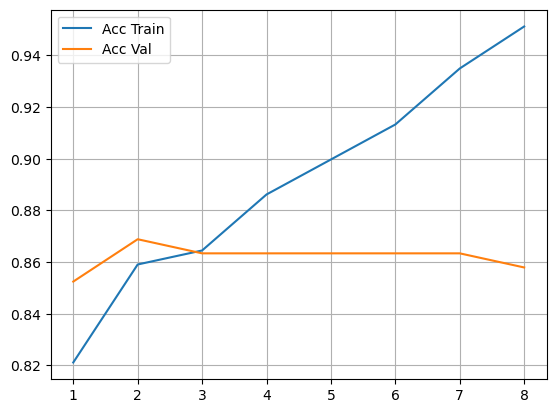

In [80]:
plt.plot(max_depth_values, acc_train_values, label = "Acc Train")
plt.plot(max_depth_values, acc_val_values, label = 'Acc Val')
plt.legend()
plt.grid(axis = 'both')
plt.show()

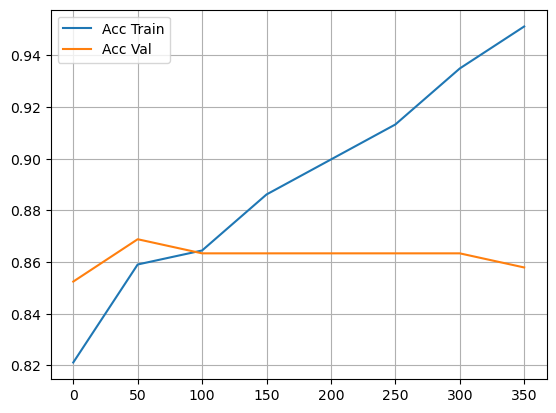

In [81]:
estimate_values = [0,50,100,150,200,250,300,350]

plt.plot(estimate_values, acc_train_values, label = "Acc Train")
plt.plot(estimate_values, acc_val_values, label = 'Acc Val')
plt.legend()
plt.grid(axis = 'both')
plt.show()

# Adaptive Boosting

In [82]:
# Using new type of ensemble called AdaBoostClassifier
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth = 3, min_samples_leaf = 60, random_state = 1),
    n_estimators = 500,
    learning_rate = 0.05,
    random_state = 1

)

acc_train_ada, acc_val_ada = evalute_model(ada_clf, x_train_scaler,
                                           x_val_scaler, y_train, y_val)

AdaBoostClassifier
Accuracy of training:  0.9214092140921409
Accuracy of valdation:  0.8743169398907104
-------------------------------------


# Gradient Boosting

In [83]:
from sklearn.ensemble import GradientBoostingClassifier

gbct_clf = GradientBoostingClassifier(max_depth = 1, n_estimators = 300,
                                      learning_rate = 0.1, random_state = 1)

acc_train_gbct, acc_val_gbct = evalute_model(gbct_clf, x_train_scaler,
                                           x_val_scaler, y_train, y_val)

GradientBoostingClassifier
Accuracy of training:  0.9051490514905149
Accuracy of valdation:  0.8579234972677595
-------------------------------------


# Comparing Results

In [84]:
# Make dictonary to put model, acc_train and acc_val.
all_results = {
    'model': [],
    'acc_train': [],
    'acc_val': []
}

# 
all_results['model'] = results['model'] + ['bagging','rf','ex','ada','gbct']
all_results['acc_train'] = results['acc_train'] + [acc_train_bag,acc_train_rf,acc_train_ex,
                                                   acc_train_ada,acc_train_gbct]
all_results['acc_val'] = results['acc_val'] + [acc_val_bag,acc_val_rf,acc_val_ex,
                                               acc_val_ada,acc_val_gbct]

In [85]:
# Using pandas to put data in Frame.
all_results_df = pd.DataFrame(all_results)

all_results_df = all_results_df.sort_values(by = 'acc_val',
                                            ascending = False, ignore_index = True)# ignore_index ==> Not interest of arrange.

In [86]:
all_results_df

,model,acc_train,acc_val
0,bagging,0.845528,0.885246
1,logistic,0.848238,0.879781
2,rf,0.956640,0.879781
3,voting_clf,0.891599,0.874317
4,ada,0.921409,0.874317
5,svc,0.899729,0.868852
6,ex,0.951220,0.857923
7,gbct,0.905149,0.857923
8,tree,0.856369,0.830601


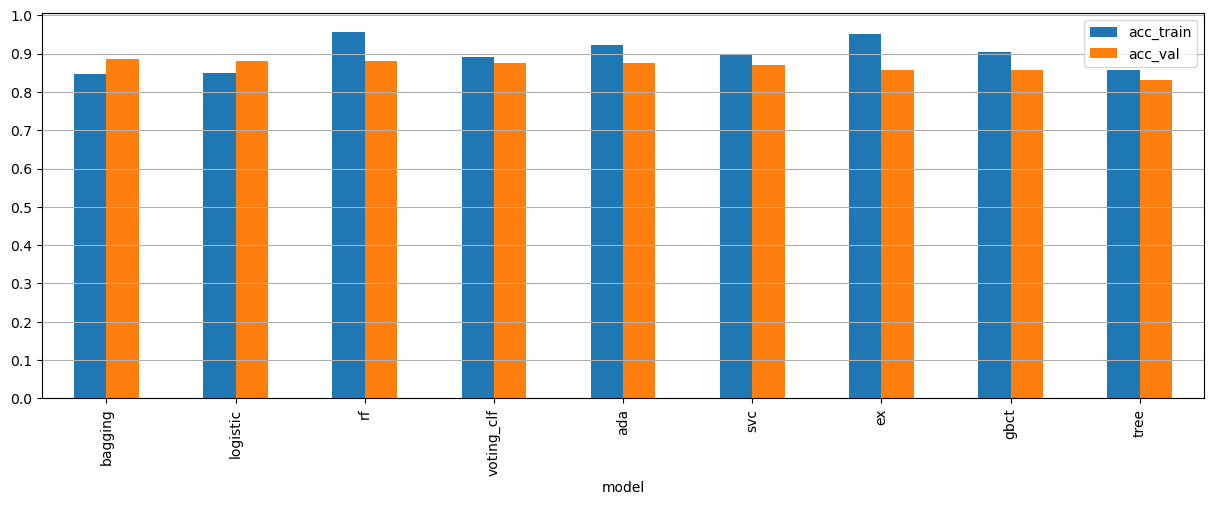

In [87]:
# Graph to compare between model.
import numpy as np

all_results_df.plot.bar(x = 'model', y = ['acc_train', 'acc_val'], figsize = (15, 5))
plt.yticks(np.arange(0.0,1.1,0.1))
plt.grid(axis = 'y')
plt.legend()
plt.show()

# Testing

In [88]:
best_model = BaggingClassifier(
    estimator=voting_clf,
    n_estimators=100,
    max_samples=0.75,
    bootstrap=True,
    random_state=1,
    n_jobs=-1
)

best_model.fit(x_train, y_train)

BaggingClassifier(estimator=VotingClassifier(estimators=[('tree',
                                                          DecisionTreeClassifier(max_depth=3,
                                                                                 random_state=1)),
                                                         ('logistic',
                                                          LogisticRegression(random_state=1)),
                                                         ('svc',
                                                          SVC(random_state=1))]),
                  max_samples=0.75, n_estimators=100, n_jobs=-1,
                  random_state=1)

In [89]:
# Train Model.
best_model.fit(x_train_scaler,y_train)

BaggingClassifier(estimator=VotingClassifier(estimators=[('tree',
                                                          DecisionTreeClassifier(max_depth=3,
                                                                                 random_state=1)),
                                                         ('logistic',
                                                          LogisticRegression(random_state=1)),
                                                         ('svc',
                                                          SVC(random_state=1))]),
                  max_samples=0.75, n_estimators=100, n_jobs=-1,
                  random_state=1)

In [90]:
# Predict the values of train and validation.
y_pred_test = best_model.predict(x_test_scaler)

In [91]:
# Calculate accuracy of train and testing.
accuracy_score(y_test,y_pred_test)

0.9130434782608695

In [92]:
# Save the complete model.
import pickle

with open('saved-model.pickle','wb')as f:
    pickle.dump(best_model,f)